# Hackathon 5: Model Showdown — Finding students who miss out on the extra grant

**SDG 8 — Decent Work and Economic Growth**

## Step 1 — Framing the problem

**User and decision:** DUO, the Dutch student finance office, wants to reach students who are probably entitled to an *aanvullende beurs* (extra grant based on parents' income) but have not applied. DUO uses this model on the parents' data to decide which students to send an information letter.

**Target:** `income`, whether a person earns more than $50K per year.

**Positive class:** `<=50K` (low income). These are the families whose children may be entitled to the extra grant.

**Which mistake is worse?**
- *False negative:* the model says the parents earn more than 50K when they actually earn less. The student never gets the letter and misses money they're entitled to, which can mean taking on extra loans or dropping out.
- *False positive:* the model says the parents earn 50K or less when they actually earn more. The student gets a letter, applies, and DUO checks their real income and says no. That costs a little time but harms no one.

A false negative is much worse, so missing a student who needs the grant is the mistake to avoid.

**Main metric:** **Balanced accuracy**, the average of two numbers: the share of low-income families the model finds (recall for `<=50K`) and the share of higher-income families it correctly leaves out. Recall alone cannot be the main metric here: 76% of the people are low income, so a model that sends everyone a letter gets a recall of 1.0 without learning anything. Balanced accuracy gives that lazy model 0.5. I still report recall for the `<=50K` class in every table, because that is the number that matters most to the student, together with precision.

**Limitation:** The data comes from the 1994 US Census, not from the Netherlands. Income levels, prices and the grant rules are different, so $50K in 1994 does not match the real DUO income limit. This notebook shows the method. A real DUO tool would need recent Dutch data, which is not public for privacy reasons.

## Step 2 — Exploring the data

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42

In [2]:
# Load the Adult (Census Income) dataset: the raw file from the UCI repository.
# It is saved next to this notebook as adult.csv; if it is not there (e.g. in Colab), it is downloaded.
DATA_URL = "https://archive.ics.uci.edu/static/public/2/data.csv"
df = pd.read_csv("adult.csv" if os.path.exists("adult.csv") else DATA_URL)
print(df.shape)
df.head()

(48842, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [3]:
# Column types
df.dtypes

age                int64
workclass         object
fnlwgt             int64
education         object
education-num      int64
marital-status    object
occupation        object
relationship      object
race              object
sex               object
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country    object
income            object
dtype: object

In [4]:
# The target has four spellings: the original test file adds a full stop ('<=50K.')
df["income"].value_counts()

income
<=50K     24720
<=50K.    12435
>50K       7841
>50K.      3846
Name: count, dtype: int64

In [5]:
# Remove the full stop so there are only two classes
df["income"] = df["income"].str.rstrip(".")
df["income"].value_counts(normalize=True).round(3)

income
<=50K    0.761
>50K     0.239
Name: proportion, dtype: float64

In [6]:
# Missing values are stored in two ways: as empty cells and as '?'
print("Empty cells:\n", df.isna().sum()[df.isna().sum() > 0])
print("\n'?' values:\n", (df == "?").sum()[(df == "?").sum() > 0])

Empty cells:
 workclass         963
occupation        966
native-country    274
dtype: int64

'?' values:
 workclass         1836
occupation        1843
native-country     583
dtype: int64


In [7]:
# Turn '?' into a real missing value so both kinds are handled the same way
df = df.replace("?", np.nan)
df.isna().sum()[df.isna().sum() > 0]

workclass         2799
occupation        2809
native-country     857
dtype: int64

In [8]:
# Duplicate rows (could end up in both train and test)
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 52


In [9]:
# Distributions of the numeric columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,48842.0,38.643585,13.710510,17.0,28.0,37.0,48.0,90.0
fnlwgt,48842.0,189664.134597,105604.025423,12285.0,117550.5,178144.5,237642.0,1490400.0
education-num,48842.0,10.078089,2.570973,1.0,9.0,10.0,12.0,16.0
capital-gain,48842.0,1079.067626,7452.019058,0.0,0.0,0.0,0.0,99999.0
capital-loss,48842.0,87.502314,403.004552,0.0,0.0,0.0,0.0,4356.0
hours-per-week,48842.0,40.422382,12.391444,1.0,40.0,40.0,45.0,99.0


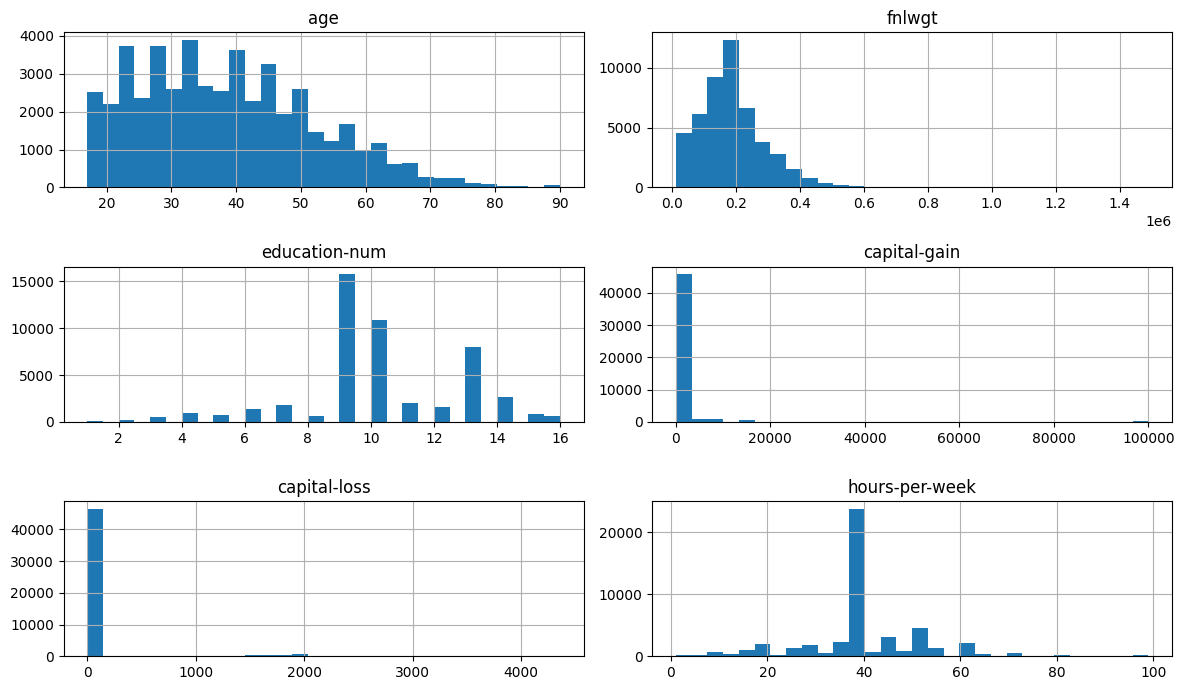

In [10]:
df.hist(figsize=(12, 7), bins=30)
plt.tight_layout()
plt.show()

In [11]:
# Impossible or suspicious values
print("capital-gain of exactly 99999:", (df["capital-gain"] == 99999).sum())
print("hours-per-week of 99:", (df["hours-per-week"] == 99).sum())
print("age range:", df["age"].min(), "-", df["age"].max())

capital-gain of exactly 99999: 244
hours-per-week of 99: 137
age range: 17 - 90


In [12]:
# Share of low income per group (sex and race)
for col in ["sex", "race"]:
    print(pd.crosstab(df[col], df["income"], normalize="index").round(3), "\n")

income  <=50K   >50K
sex                 
Female  0.891  0.109
Male    0.696  0.304 

income              <=50K   >50K
race                            
Amer-Indian-Eskimo  0.883  0.117
Asian-Pac-Islander  0.731  0.269
Black               0.879  0.121
Other               0.877  0.123
White               0.746  0.254 



**What we found and decided:**
- **Size:** 48,842 rows, 14 features.
- **Target labels:** part of the data wrote the classes with a full stop (`<=50K.`). We removed it, leaving two classes.
- **Class balance:** 76% `<=50K`, 24% `>50K`. A model that always says "low income" would already get 76% accuracy, so accuracy is not a useful metric here.
- **Missing values:** stored both as empty cells and as `?`. We turned `?` into real missing values. They appear in `workclass`, `occupation` and `native-country` and will be filled in inside the Pipeline (step 4), so that only training data is used.
- **Duplicates:** 52 duplicate rows. We remove them before the split so the same person cannot be in both train and test.
- **Suspicious values:** 244 rows have `capital-gain` of exactly 99,999 and 137 have `hours-per-week` of 99. These look like upper limits of the census form rather than real values. We keep them, because they still mean "very high", but we note them.
- **Columns we will drop:** `fnlwgt` is a census weighting number, not a characteristic of the person. `education` holds the same information as `education-num`.
- **Leakage check:** no column is only known after the income is known.
- **Groups:** low income is much more common among women (89%) than men (70%), and among Black (88%) than White (75%) people. The model will learn these patterns, so in step 7 we check whether it makes more mistakes for some groups.

## Step 3 — Split first

We set aside 20% of the rows as a test set before any cleaning, scaling or tuning. The split is stratified, so the training and test set both have 76% low income, and it uses `random_state=42`, so the numbers are the same on every run. Before the split we removed the 52 duplicate rows and dropped `fnlwgt` and `education` (reasons in step 2). The test set is used only once, in step 7.

In [13]:
from sklearn.model_selection import train_test_split

# Decisions from step 2: remove duplicates and the two columns we do not use
df = df.drop_duplicates().drop(columns=["fnlwgt", "education"])

X = df.drop(columns="income")
y = (df["income"] == "<=50K").astype(int)   # 1 = low income (positive class)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, " share of low income:", round(y_train.mean(), 3))
print("Test: ", X_test.shape, " share of low income:", round(y_test.mean(), 3))

Train: (39032, 12)  share of low income: 0.761
Test:  (9758, 12)  share of low income: 0.761


## Step 4 — Pre-processing inside a Pipeline

All pre-processing happens inside a Pipeline, so it is learned from the training data only.
- **Numeric columns:** missing values are filled with the median, then the columns are scaled. KNN measures the distance between people, so without scaling `capital-gain` (0 to 99,999) would count much more than `education-num` (1 to 16). Logistic regression also needs it, because its `C` setting treats all columns the same only when they are on the same scale.
- **Categorical columns:** missing values are filled with the most common value, then each category becomes its own yes/no column (one-hot encoding).

No rows are dropped in this step.

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_cols = X_train.select_dtypes(include="number").columns.tolist()
cat_cols = X_train.select_dtypes(exclude="number").columns.tolist()
print("Numeric:", num_cols)
print("Categorical:", cat_cols)

preprocess = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                      ("scale", StandardScaler())]), num_cols),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore"))]), cat_cols),
])

Numeric: ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical: ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


## Step 5 — Baseline

The baseline is a `DummyClassifier` that always predicts the most common class, low income. It finds every low-income family (recall 1.0), but only because it flags everyone, so its balanced accuracy is 0.5. Every model has to beat 0.5 on balanced accuracy.

In [15]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"balanced_accuracy": "balanced_accuracy", "recall": "recall", "precision": "precision"}

baseline = Pipeline([("prep", preprocess), ("model", DummyClassifier(strategy="most_frequent"))])
base_cv = cross_validate(baseline, X_train, y_train, cv=cv, scoring=scoring, return_train_score=True)
for name in scoring:
    print(f"{name:18s} {base_cv['test_' + name].mean():.3f}")

balanced_accuracy  0.500
recall             1.000
precision          0.761


## Step 6 — Tuning with cross-validation

All three models are tuned on the training set only, with the same 5 folds and the same scores. The best setting is the one with the highest balanced accuracy.
- **KNN:** `n_neighbors`, how many neighbours vote.
- **Logistic regression:** `C`, how closely it may follow the training data, and `class_weight`.
- **Random forest (our own choice):** many decision trees that vote together. We tune `max_depth`, how deep the trees may go, and `class_weight`.

`class_weight="balanced"` makes a mistake on the smaller group (`>50K`) count as much as a mistake on the larger group.

In [16]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

models = {
    "KNN": (KNeighborsClassifier(),
            {"model__n_neighbors": [5, 11, 21, 31, 51]}),
    "Logistic regression": (LogisticRegression(max_iter=1000),
            {"model__C": [0.01, 0.1, 1, 10],
             "model__class_weight": [None, "balanced"]}),
    "Random forest": (RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
            {"model__max_depth": [5, 10, 20, None],
             "model__class_weight": [None, "balanced"]}),
}

searches = {}
for name, (model, grid) in models.items():
    pipe = Pipeline([("prep", preprocess), ("model", model)])
    search = GridSearchCV(pipe, grid, cv=cv, scoring=scoring,
                          refit="balanced_accuracy", return_train_score=True, n_jobs=2)
    search.fit(X_train, y_train)
    searches[name] = search
    print(name, "best settings:", search.best_params_)

KNN best settings: {'model__n_neighbors': 31}


Logistic regression best settings: {'model__C': 10, 'model__class_weight': 'balanced'}


Random forest best settings: {'model__class_weight': 'balanced', 'model__max_depth': 20}


In [17]:
# Mean and spread over the 5 folds for the best setting of each model
rows = [{"model": "Baseline",
         "CV balanced accuracy": base_cv["test_balanced_accuracy"].mean(),
         "spread (std)": base_cv["test_balanced_accuracy"].std(),
         "CV recall": base_cv["test_recall"].mean(),
         "CV precision": base_cv["test_precision"].mean()}]
for name, s in searches.items():
    r, i = s.cv_results_, s.best_index_
    rows.append({"model": name,
                 "CV balanced accuracy": r["mean_test_balanced_accuracy"][i],
                 "spread (std)": r["std_test_balanced_accuracy"][i],
                 "CV recall": r["mean_test_recall"][i],
                 "CV precision": r["mean_test_precision"][i]})
cv_table = pd.DataFrame(rows).set_index("model").round(3)
cv_table

,CV balanced accuracy,spread (std),CV recall,CV precision
model,,,,
Baseline,0.500,0.000,1.000,0.761
KNN,0.766,0.006,0.923,0.882
Logistic regression,0.820,0.005,0.793,0.943
Random forest,0.826,0.006,0.831,0.937


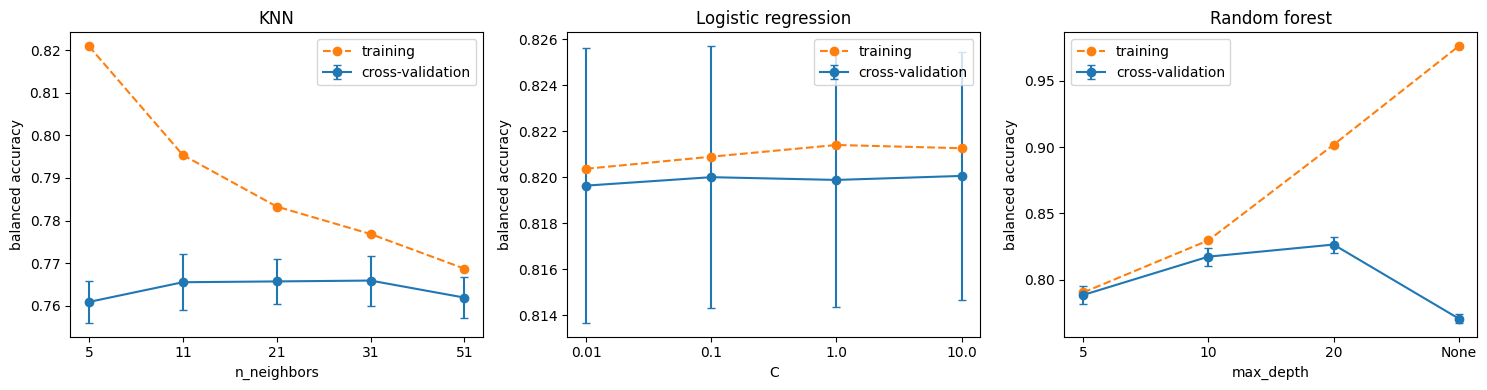

In [18]:
# Score against the main hyperparameter of each model
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
params = {"KNN": "model__n_neighbors", "Logistic regression": "model__C", "Random forest": "model__max_depth"}
for ax, (name, param) in zip(axes, params.items()):
    r = pd.DataFrame(searches[name].cv_results_)
    if "param_model__class_weight" in r:
        best_cw = searches[name].best_params_["model__class_weight"]
        r = r[r["param_model__class_weight"].map(str) == str(best_cw)]
    x = r["param_" + param].map(str)
    ax.errorbar(x, r["mean_test_balanced_accuracy"], yerr=r["std_test_balanced_accuracy"],
                marker="o", capsize=3, label="cross-validation")
    ax.plot(x, r["mean_train_balanced_accuracy"], marker="o", linestyle="--", label="training")
    ax.set_title(name)
    ax.set_xlabel(param.replace("model__", ""))
    ax.set_ylabel("balanced accuracy")
    ax.legend()
plt.tight_layout()
plt.show()

**What the tuning shows:**
- **KNN:** the score hardly changes with `n_neighbors` (0.761 to 0.766). With 5 neighbours the training score is clearly higher than the cross-validation score (0.821 vs 0.761), which is overfitting. With 31 the gap is almost gone.
- **Logistic regression:** `C` makes almost no difference. `class_weight="balanced"` does: 0.765 becomes 0.820.
- **Random forest:** without a depth limit the training score goes up to 0.976 while the cross-validation score drops to 0.771. That is overfitting. A depth of 20 is best.

The spread over the folds is about 0.006 for every model, so a difference smaller than that is luck.

## Step 7 — Evaluating once on the test set

In [19]:
from sklearn.metrics import balanced_accuracy_score, precision_score, recall_score, f1_score

# The test set is opened here, once. The baseline and the three tuned models all predict the same test rows.
baseline.fit(X_train, y_train)
final_models = {"Baseline": baseline}
for name, s in searches.items():
    final_models[name] = s.best_estimator_
test_pred = {name: m.predict(X_test) for name, m in final_models.items()}

rows = []
for name, pred in test_pred.items():
    if name == "Baseline":
        settings = "-"
        train_score = base_cv["train_balanced_accuracy"].mean()
        cv_mean = base_cv["test_balanced_accuracy"].mean()
        cv_std = base_cv["test_balanced_accuracy"].std()
    else:
        s = searches[name]
        settings = ", ".join(f"{k.replace('model__', '')}={v}" for k, v in s.best_params_.items())
        train_score = s.cv_results_["mean_train_balanced_accuracy"][s.best_index_]
        cv_mean = s.cv_results_["mean_test_balanced_accuracy"][s.best_index_]
        cv_std = s.cv_results_["std_test_balanced_accuracy"][s.best_index_]
    rows.append({"model": name,
                 "best settings": settings,
                 "train bal. acc.": round(train_score, 3),
                 "CV bal. acc. (mean ± std)": f"{cv_mean:.3f} ± {cv_std:.3f}",
                 "test bal. acc.": round(balanced_accuracy_score(y_test, pred), 3),
                 "test precision": round(precision_score(y_test, pred), 3),
                 "test recall": round(recall_score(y_test, pred), 3),
                 "test F1": round(f1_score(y_test, pred), 3)})
comparison = pd.DataFrame(rows).set_index("model")
comparison

,best settings,train bal. acc.,CV bal. acc. (mean ± std),test bal. acc.,test precision,test recall,test F1
model,,,,,,,
Baseline,-,0.500,0.500 ± 0.000,0.500,0.761,1.000,0.864
KNN,n_neighbors=31,0.777,0.766 ± 0.006,0.770,0.884,0.925,0.904
Logistic regression,"C=10, class_weight=balanced",0.821,0.820 ± 0.005,0.823,0.944,0.795,0.863
Random forest,"class_weight=balanced, max_depth=20",0.902,0.826 ± 0.006,0.827,0.938,0.830,0.881


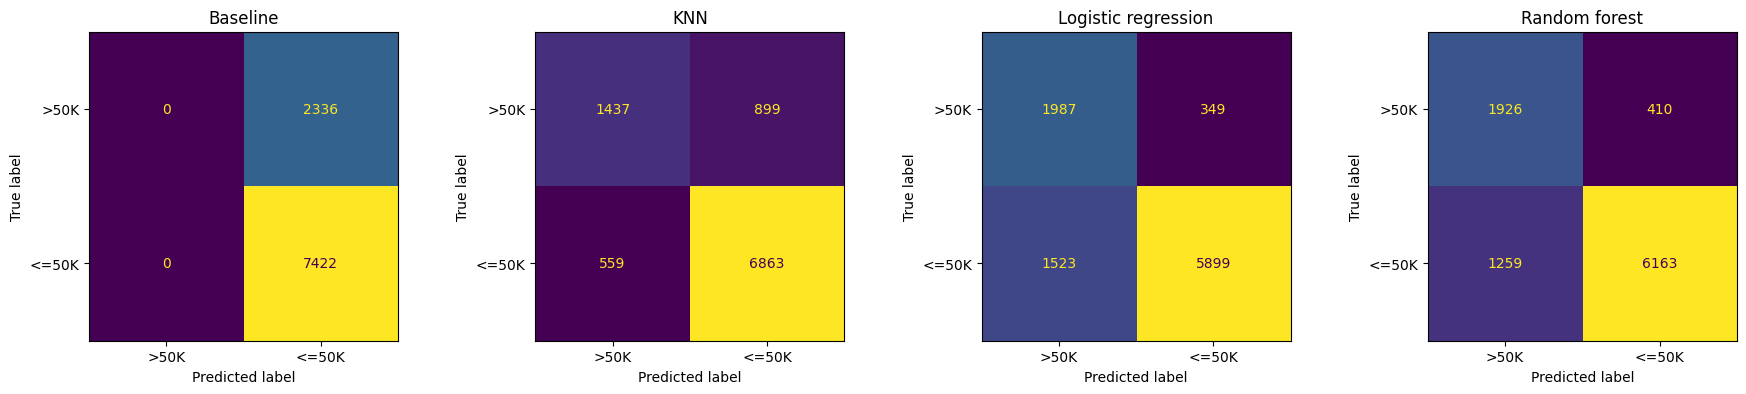

In [20]:
# Confusion matrix per model (rows = real income, columns = what the model said)
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, pred) in zip(axes, test_pred.items()):
    ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=[">50K", "<=50K"],
                                            ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

**What the test set shows:**
- All three models beat the baseline (0.500) on balanced accuracy.
- The test scores are almost the same as the cross-validation scores (random forest: 0.827 vs 0.826), so cross-validation gave an honest estimate.
- KNN and logistic regression have nearly the same training, cross-validation and test score, so they do not overfit. The random forest scores 0.902 on training data and 0.826 in cross-validation, so it overfits somewhat, but it is still the best on new data.
- Of the 7,422 low-income people in the test set, KNN misses 559, the random forest 1,259 and logistic regression 1,523. KNN pays for this by sending a letter to 899 of the 2,336 higher-income people. The random forest does that for 410 and logistic regression for 349.

## Step 8 — Looking at the errors

In [21]:
# The model we look at more closely: the one with the best cross-validation score
best_name = cv_table["CV balanced accuracy"].idxmax()
best_model = final_models[best_name]
best_pred = test_pred[best_name]
print("Best model in cross-validation:", best_name)

errors = X_test.copy()
errors["real"] = y_test
errors["predicted"] = best_pred
missed = errors[(errors["real"] == 1) & (errors["predicted"] == 0)]   # low income, but no letter
found = errors[(errors["real"] == 1) & (errors["predicted"] == 1)]    # low income, gets a letter
print("Low-income people in the test set:", len(missed) + len(found))
print("Missed (false negatives):", len(missed))

# Who are the missed people, compared with the low-income people the model did find?
pd.DataFrame({
    "missed": [missed["age"].mean(), missed["education-num"].mean(), missed["hours-per-week"].mean(),
               (missed["marital-status"] == "Married-civ-spouse").mean(), (missed["sex"] == "Male").mean()],
    "found": [found["age"].mean(), found["education-num"].mean(), found["hours-per-week"].mean(),
              (found["marital-status"] == "Married-civ-spouse").mean(), (found["sex"] == "Male").mean()],
}, index=["mean age", "mean education-num", "mean hours per week", "share married", "share male"]).round(2)

Best model in cross-validation: Random forest
Low-income people in the test set: 7422
Missed (false negatives): 1259


,missed,found
mean age,43.73,35.81
mean education-num,10.64,9.36
mean hours per week,44.51,37.79
share married,0.96,0.21
share male,0.91,0.55


In [22]:
# Performance per group: does the model make the same mistakes for everyone?
def group_table(column):
    rows = []
    for group, idx in X_test.groupby(column).groups.items():
        real, pred = y_test.loc[idx], pd.Series(best_pred, index=y_test.index).loc[idx]
        rows.append({column: group,
                     "people": len(idx),
                     "share low income": round(real.mean(), 3),
                     "recall (low income found)": round(recall_score(real, pred), 3),
                     "high income correctly left out": round(recall_score(real, pred, pos_label=0), 3),
                     "balanced accuracy": round(balanced_accuracy_score(real, pred), 3)})
    return pd.DataFrame(rows).set_index(column)

display(group_table("sex"))
display(group_table("race"))

,people,share low income,recall (low income found),high income correctly left out,balanced accuracy
sex,,,,,
Female,3274,0.888,0.963,0.628,0.796
Male,6484,0.696,0.745,0.861,0.803


,people,share low income,recall (low income found),high income correctly left out,balanced accuracy
race,,,,,
Amer-Indian-Eskimo,83,0.940,0.910,0.200,0.555
Asian-Pac-Islander,300,0.747,0.857,0.750,0.804
Black,962,0.881,0.933,0.649,0.791
Other,71,0.873,0.968,0.778,0.873
White,8342,0.744,0.813,0.838,0.826


**What we found:**

The random forest misses 1,259 of the 7,422 low-income people (17%). The missed people look like high earners: 96% are married (21% of the people it finds), 91% are men, they are older (44 vs 36) and work more hours (45 vs 38). The model has learned "married man with a full-time job = high income" and misses the low-income families that fit that picture.

**Per group:** the model finds 96% of low-income women but only 75% of low-income men. For women the opposite mistake is more common: only 63% of higher-income women are correctly left out, against 86% of men. By race, recall is lower for White (0.813) than for Black people (0.933). The groups Amer-Indian-Eskimo and Other have fewer than 100 people in the test set, which is too few to say anything.

## Step 9 — Recommendation

We recommend the **random forest** to DUO, with conditions.
- The random forest and logistic regression are tied on the main metric (0.826 vs 0.820 in cross-validation, with a spread of 0.006). Of the two, the random forest finds more low-income families (recall 0.830 vs 0.795), which is 264 more students in the test set.
- Logistic regression is easier to explain. If DUO has to explain to a student why they did or did not get a letter, it is a reasonable alternative with almost the same score.
- KNN has the highest recall (0.925), but it sends a letter to 38% of the higher-income people and has the lowest score on the main metric.

**Conditions:**
- The model misses 17% of the low-income families, mostly married men, so the letter cannot be the only way students hear about the grant.
- A false positive costs little, so DUO could send the letter at a lower probability than 50%. That threshold has to be chosen with cross-validation, which we did not do here.
- The model must not be used on Dutch students before it is trained again on recent Dutch data.

## Step 10 — Using the model

A made-up parent: a 46-year-old divorced woman who works 32 hours a week in a service job. The model returns its prediction and the probability. DUO should always see the probability, because 55% and 99% are different messages.

In [23]:
# A made-up family: one parent's data goes in, a prediction and a probability come out
new_case = pd.DataFrame([{
    "age": 46, "workclass": "Private", "education-num": 9, "marital-status": "Divorced",
    "occupation": "Other-service", "relationship": "Unmarried", "race": "White", "sex": "Female",
    "capital-gain": 0, "capital-loss": 0, "hours-per-week": 32, "native-country": "United-States",
}])

prediction = best_model.predict(new_case)[0]
probability = best_model.predict_proba(new_case)[0, 1]   # column 1 = chance of low income (<=50K)

print("Prediction:", "<=50K (low income): send the letter" if prediction == 1 else ">50K: no letter")
print(f"Probability of low income: {probability:.0%}")

Prediction: <=50K (low income): send the letter
Probability of low income: 99%
